# Importing Library

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom , RandomTranslation , RandomContrast , RandomBrightness
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.regularizers import l2

2025-09-28 21:33:47.523097: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Importing Dataset

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 123
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 19278 files belonging to 4 classes.
Using 15423 files for training.


I0000 00:00:1759073645.259956     756 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 19278 files belonging to 4 classes.
Using 3855 files for validation.
Found 7126 files belonging to 4 classes.


# Data Preprocessing

In [3]:
data_augmentation = tf.keras.Sequential([
    RandomRotation(factor=(-0.025, 0.025)),
    RandomTranslation(height_factor=0.05, width_factor=0.05),
    RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05)),
    RandomContrast(factor=0.1),
    RandomFlip(mode="horizontal"),
    RandomBrightness(factor=0.1)
], name="data_augmentation")

def cutmix_sparse(batch_x, batch_y, alpha=1.0):
    batch_size = tf.shape(batch_x)[0]

    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_x = tf.gather(batch_x, indices)
    shuffled_y = tf.gather(batch_y, indices)

    lam = tf.random.uniform([], 0, 1)

    H, W = IMG_SIZE
    r_x = tf.cast(W * tf.random.uniform([], 0, 1), tf.int32)
    r_y = tf.cast(H * tf.random.uniform([], 0, 1), tf.int32)
    r_w = tf.cast(W * tf.math.sqrt(1 - lam), tf.int32)
    r_h = tf.cast(H * tf.math.sqrt(1 - lam), tf.int32)

    x1 = tf.clip_by_value(r_x - r_w // 2, 0, W)
    y1 = tf.clip_by_value(r_y - r_h // 2, 0, H)
    x2 = tf.clip_by_value(r_x + r_w // 2, 0, W)
    y2 = tf.clip_by_value(r_y + r_h // 2, 0, H)

    mask = tf.ones([y2 - y1, x2 - x1, 3])
    pad_top = y1
    pad_left = x1
    pad_bottom = H - y2
    pad_right = W - x2
    mask = tf.pad(mask, [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]])
    mask = 1 - mask

    mixed_x = batch_x * mask + shuffled_x * (1 - mask)

    mixed_y = tf.where(lam > 0.5, batch_y, shuffled_y)

    return mixed_x, mixed_y


train_ds_augmented = train_ds.map(
    lambda x, y: cutmix_sparse(x, y), num_parallel_calls=AUTOTUNE
)


# Model Creation

In [4]:
def build_model(input_shape=IMG_SIZE+(3,), num_classes=4):
    base_model = ResNet50(
        include_top=False,
        input_shape=input_shape,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = data_augmentation(inputs)      
    x = base_model(x, training=False)    
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation="softmax", kernel_regularizer=l2(1e-4))(x)
    model = Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=1e-3,
        first_decay_steps=1000,
        t_mul=2.0,
        m_mul=0.8,
        alpha=1e-6
    )
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=[SparseCategoricalAccuracy(name="accuracy")]
    )
    return model, base_model

model, base_model = build_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Training The Model

In [5]:
history1 = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
)

Epoch 1/10


2025-09-28 21:34:32.233765: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


964/964 ━━━━━━━━━━━━━━━━━━━━ 76s 70ms/step - accuracy: 0.5492 - loss: 1.0501 - val_accuracy: 0.7188 - val_loss: 0.7013
Epoch 2/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 102s 106ms/step - accuracy: 0.5824 - loss: 0.9902 - val_accuracy: 0.7468 - val_loss: 0.6487
Epoch 3/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 66s 68ms/step - accuracy: 0.6110 - loss: 0.9441 - val_accuracy: 0.7642 - val_loss: 0.6311
Epoch 4/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 65s 68ms/step - accuracy: 0.6057 - loss: 0.9537 - val_accuracy: 0.7699 - val_loss: 0.6189
Epoch 5/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 65s 68ms/step - accuracy: 0.6204 - loss: 0.9202 - val_accuracy: 0.7647 - val_loss: 0.6231
Epoch 6/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 65s 68ms/step - accuracy: 0.6347 - loss: 0.8866 - val_accuracy: 0.7686 - val_loss: 0.6118
Epoch 7/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 66s 68ms/step - accuracy: 0.6460 - loss: 0.8700 - val_accuracy: 0.7803 - val_loss: 0.5909
Epoch 8/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 65s 68ms/step - accuracy: 0.6280 - loss: 0.8959 - val_accur

# Fine Tuning

## Total Layers of The Base Model

In [6]:
print("Base model has", len(base_model.layers), "layers.")

Base model has 175 layers.


## Tuning Process

In [7]:
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True


model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5), 
    loss="sparse_categorical_crossentropy",
    metrics=[SparseCategoricalAccuracy(name="accuracy")]
)

history2 = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=25,
    callbacks=[
        ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss"),
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)
    ]
)

Epoch 1/25
964/964 ━━━━━━━━━━━━━━━━━━━━ 144s 134ms/step - accuracy: 0.6369 - loss: 0.9134 - val_accuracy: 0.8376 - val_loss: 0.4487 - learning_rate: 1.0000e-04
Epoch 2/25
964/964 ━━━━━━━━━━━━━━━━━━━━ 126s 130ms/step - accuracy: 0.7007 - loss: 0.7703 - val_accuracy: 0.8560 - val_loss: 0.4091 - learning_rate: 1.0000e-04
Epoch 3/25
964/964 ━━━━━━━━━━━━━━━━━━━━ 126s 131ms/step - accuracy: 0.7122 - loss: 0.7519 - val_accuracy: 0.8695 - val_loss: 0.3896 - learning_rate: 1.0000e-04
Epoch 4/25
964/964 ━━━━━━━━━━━━━━━━━━━━ 126s 130ms/step - accuracy: 0.7249 - loss: 0.7105 - val_accuracy: 0.8817 - val_loss: 0.3137 - learning_rate: 1.0000e-04
Epoch 5/25
964/964 ━━━━━━━━━━━━━━━━━━━━ 123s 127ms/step - accuracy: 0.7366 - loss: 0.6901 - val_accuracy: 0.8706 - val_loss: 0.3565 - learning_rate: 1.0000e-04
Epoch 6/25
964/964 ━━━━━━━━━━━━━━━━━━━━ 128s 132ms/step - accuracy: 0.7379 - loss: 0.6845 - val_accuracy: 0.8872 - val_loss: 0.3093 - learning_rate: 1.0000e-04
Epoch 7/25
964/964 ━━━━━━━━━━━━━━━━━━━━ 

# Evaluate

In [8]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

446/446 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.9144 - loss: 0.2345
Test Accuracy: 0.9143979549407959


# Confusion Matrix

2025-09-28 22:40:01.290001: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


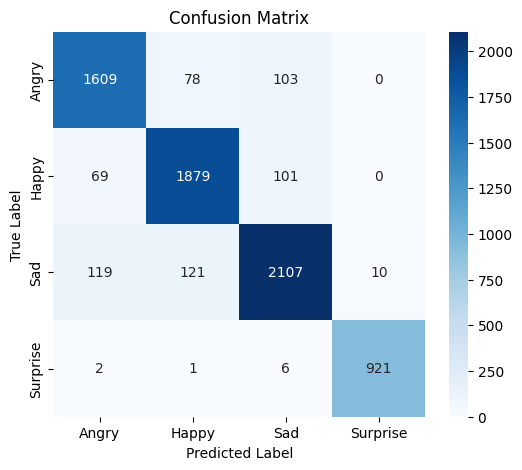

Classification Report:

              precision    recall  f1-score   support

       Angry     0.8944    0.8989    0.8966      1790
       Happy     0.9038    0.9170    0.9104      2049
         Sad     0.9094    0.8939    0.9016      2357
    Surprise     0.9893    0.9903    0.9898       930

    accuracy                         0.9144      7126
   macro avg     0.9242    0.9250    0.9246      7126
weighted avg     0.9144    0.9144    0.9144      7126



In [9]:
class_names = ['Angry', 'Happy', 'Sad', 'Surprise']
all_preds = []
all_labels = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)  
    all_preds.append(preds)
    all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

y_true = all_labels
y_pred = np.argmax(all_preds, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


# Plot

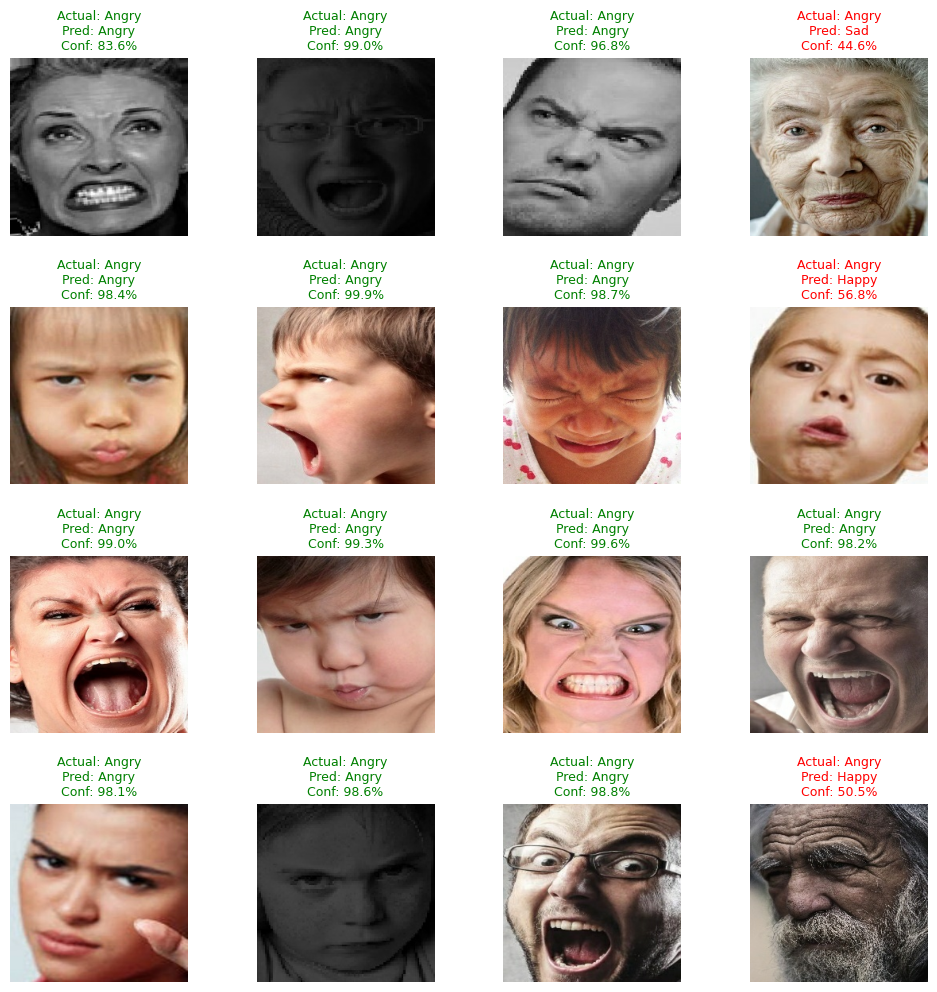

In [15]:
def plot_actual_vs_predicted_batchwise(model, dataset, class_names, num_samples=16):
    for images, labels in dataset.take(1):
        preds = model.predict(images, verbose=0)
        images, labels, preds = images[:num_samples], labels[:num_samples], preds[:num_samples]

        rows = cols = int(np.ceil(np.sqrt(num_samples)))
        fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
        axes = axes.flatten()

        pred_labels = np.argmax(preds, axis=1)

        for i in range(num_samples):
            img = images[i].numpy().astype("uint8")
            axes[i].imshow(img)
            true_label = class_names[labels[i]]
            predicted_label = class_names[pred_labels[i]]
            confidence = preds[i][pred_labels[i]]
            color = 'green' if labels[i] == pred_labels[i] else 'red'
            axes[i].set_title(
                f"Actual: {true_label}\nPred: {predicted_label}\nConf: {confidence*100:.1f}%",
                fontsize=9, color=color
            )
            axes[i].axis('off')

        for j in range(num_samples, len(axes)):
            axes[j].axis('off')

        fig.subplots_adjust(wspace=0.3, hspace=0.4)
        plt.show()

class_names = ['Angry', 'Happy', 'Sad', 'Surprise']
plot_actual_vs_predicted_batchwise(model, test_ds, class_names, num_samples=16)
